In [1]:
# Call the CoT results file (Results_Parameter_Combinations_CoT.xlsx) in the current directory.
import pandas as pd
import os

file_path = 'Results_Parameter_Combinations_CoT.xlsx'
if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    columns_to_select = [
        'Following_Time',
        'TTC',
        'Text_Version',
        'Traffic_Behind',
        'Passenger_Hurry',
        'Decision'
    ]
    df = df[columns_to_select]
    df['Passenger_Hurry'] = df['Passenger_Hurry'].fillna('not in a hurry')
    # pandas' read_excel treats the literal string "None" as a missing value
    # by default, so rows with no traffic behind come back as NaN here --
    # restore them before mapping to Yes/No.
    df['Traffic_Behind'] = df['Traffic_Behind'].fillna('None')
    df['Text_Version'] = df['Text_Version'].replace({
        'Unlimited': 'LLM: No-limit',
        'Limited': 'LLM: Few-sentences'})
    df['Traffic_Behind'] = df['Traffic_Behind'].replace({
        'One vehicle behind at 10 m distance': 'Yes',
        'None': 'No'})
    df['Passenger_Hurry'] = df['Passenger_Hurry'].replace({
        'in hurry': 'Yes',
        'not in a hurry': 'No'})
    df['Condition'] = "Behind(" + df['Traffic_Behind'] + ") + Hurry(" + df['Passenger_Hurry'] + ")"
    display(df)
else:
    print(f"The file {file_path} does not exist in the current directory.")

,Following_Time,TTC,Text_Version,Traffic_Behind,Passenger_Hurry,Decision,Condition
0,12,1.7,LLM: No-limit,No,No,0,Behind(No) + Hurry(No)
1,12,1.7,LLM: No-limit,No,No,0,Behind(No) + Hurry(No)
2,12,1.7,LLM: No-limit,No,No,0,Behind(No) + Hurry(No)
3,12,1.7,LLM: No-limit,No,No,0,Behind(No) + Hurry(No)
4,12,1.7,LLM: No-limit,No,No,0,Behind(No) + Hurry(No)
...,...,...,...,...,...,...,...
3595,24,8.5,LLM: Few-sentences,Yes,Yes,0,Behind(Yes) + Hurry(Yes)
3596,24,8.5,LLM: Few-sentences,Yes,Yes,0,Behind(Yes) + Hurry(Yes)
3597,24,8.5,LLM: Few-sentences,Yes,Yes,0,Behind(Yes) + Hurry(Yes)
3598,24,8.5,LLM: Few-sentences,Yes,Yes,0,Behind(Yes) + Hurry(Yes)


In [2]:
# Group by the unique combination of columns
grouped_df = df.groupby(["Following_Time", "TTC", "Text_Version", "Traffic_Behind", "Passenger_Hurry"])

# Calculate the overtaking rate (Decision == 1) as a percentage
result = grouped_df["Decision"].apply(lambda x: (x.sum() / len(x)) * 100 if len(x) > 0 else 0).reset_index()

result

,Following_Time,TTC,Text_Version,Traffic_Behind,Passenger_Hurry,Decision
0,12,1.7,LLM: Few-sentences,No,No,0.000000
1,12,1.7,LLM: Few-sentences,No,Yes,0.000000
2,12,1.7,LLM: Few-sentences,Yes,No,0.000000
3,12,1.7,LLM: Few-sentences,Yes,Yes,0.000000
4,12,1.7,LLM: No-limit,No,No,0.000000
...,...,...,...,...,...,...
115,24,8.5,LLM: Few-sentences,Yes,Yes,0.000000
116,24,8.5,LLM: No-limit,No,No,80.000000
117,24,8.5,LLM: No-limit,No,Yes,20.000000
118,24,8.5,LLM: No-limit,Yes,No,73.333333


In [3]:
result.to_csv('aggregated_results_CoT.csv', index=False)

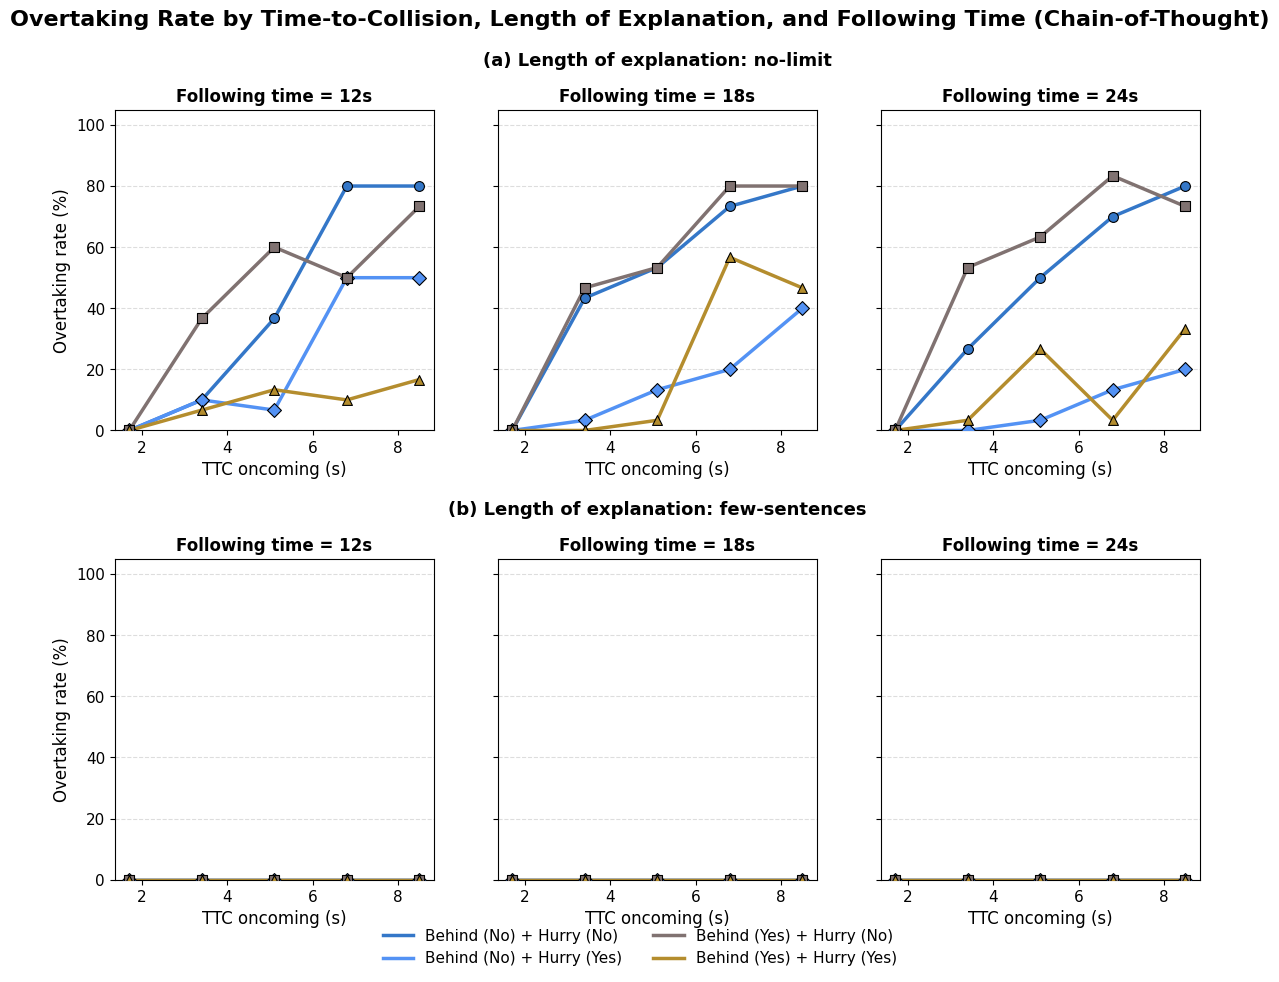

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Copy and format condition labels
df_plot = result.copy()
df_plot["Condition"] = "Behind (" + df_plot["Traffic_Behind"] + ") + Hurry (" + df_plot["Passenger_Hurry"] + ")"

# Step 2: Color palette and marker shapes
colors = {
    "Behind (No) + Hurry (No)": "#3477C8",
    "Behind (No) + Hurry (Yes)": "#5392F4",
    "Behind (Yes) + Hurry (No)": "#807271",
    "Behind (Yes) + Hurry (Yes)": "#B48D2E",
}

markers = {
    "Behind (No) + Hurry (No)": "o",
    "Behind (No) + Hurry (Yes)": "D",
    "Behind (Yes) + Hurry (No)": "s",
    "Behind (Yes) + Hurry (Yes)": "^",
}

# Fixed order for consistent legend + readability
condition_order = [
    "Behind (No) + Hurry (No)",
    "Behind (No) + Hurry (Yes)",
    "Behind (Yes) + Hurry (No)",
    "Behind (Yes) + Hurry (Yes)",
]

# Step 3: Create 2x3 plot grid
fig, axs = plt.subplots(2, 3, figsize=(14, 10), sharey=True)
fig.subplots_adjust(hspace=0.4)

fig.suptitle(
    "Overtaking Rate by Time-to-Collision, Length of Explanation, and Following Time (Chain-of-Thought)",
    fontsize=16, fontweight="bold"
)

text_versions = ["LLM: No-limit", "LLM: Few-sentences"]
following_times = [12, 18, 24]

legend_handles = {}

for row, text_version in enumerate(text_versions):
    for col, ft in enumerate(following_times):
        ax = axs[row, col]
        subset = df_plot[(df_plot["Text_Version"] == text_version) & (df_plot["Following_Time"] == ft)]

        for condition in condition_order:
            cond_data = subset[subset["Condition"] == condition]
            if len(cond_data) < 2:
                continue

            cond_data = cond_data.sort_values("TTC")
            x_vals = cond_data["TTC"].values
            y_vals = cond_data["Decision"].values

            line, = ax.plot(
                x_vals, y_vals,
                color=colors[condition],
                linewidth=2.5,
                label=condition
            )

            ax.scatter(
                x_vals, y_vals,
                color=colors[condition],
                marker=markers[condition],
                edgecolors="black",
                linewidths=0.8,
                s=50,
                zorder=3
            )

            if condition not in legend_handles:
                legend_handles[condition] = line

        ax.set_title(f"Following time = {ft}s", fontsize=12, fontweight="semibold")
        ax.set_xlabel("TTC oncoming (s)", fontsize=12)
        if col == 0:
            ax.set_ylabel("Overtaking rate (%)", fontsize=12)

        ax.set_ylim(0, 105)
        ax.tick_params(axis="both", labelsize=11)

        ax.grid(axis="y", linestyle="--", color="#DDDDDD", linewidth=0.8)
        ax.grid(axis="x", visible=False)

handles = [legend_handles[c] for c in condition_order if c in legend_handles]
labels = [c for c in condition_order if c in legend_handles]

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.01)
)

fig.canvas.draw()

left = axs[0, 0].get_position().x0
right = axs[0, 2].get_position().x1
x_center = 0.5 * (left + right)

top_row_y = axs[0, 0].get_position().y1
bottom_row_y = axs[1, 0].get_position().y1

fig.text(
    x_center, top_row_y + 0.04,
    "(a) Length of explanation: no-limit",
    ha="center", va="bottom",
    fontsize=13, fontweight="bold"
)

fig.text(
    x_center, bottom_row_y + 0.04,
    "(b) Length of explanation: few-sentences",
    ha="center", va="bottom",
    fontsize=13, fontweight="bold"
)

plt.savefig("overtaking_rate_plot_CoT.png", dpi=300, bbox_inches="tight")
plt.show()